--- 1. Loading Data ---
Data loaded successfully from 1730285881-Airbnb_Open_Data.csv. Shape: (101338, 26)

--- 2. Cleaning 'price' and 'service_fee' ---

--- 3.1. Generating Price Distribution Plot (price_distribution.png) ---
--- 3.2. Generating Listings by Neighbourhood Group Plot (listings_by_group.png) ---


/tmp/ipython-input-877295990.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=listings_by_group.index, y=listings_by_group.values, palette='viridis')


--- 3.3. Generating Listings by Room Type Plot (room_type_pie.png) ---
--- 3.4. Generating Geographical Distribution Plot (geographical_distribution.png) ---

--- Project Complete ---
Four image files have been saved to your session: price_distribution.png, listings_by_group.png, room_type_pie.png, and geographical_distribution.png.


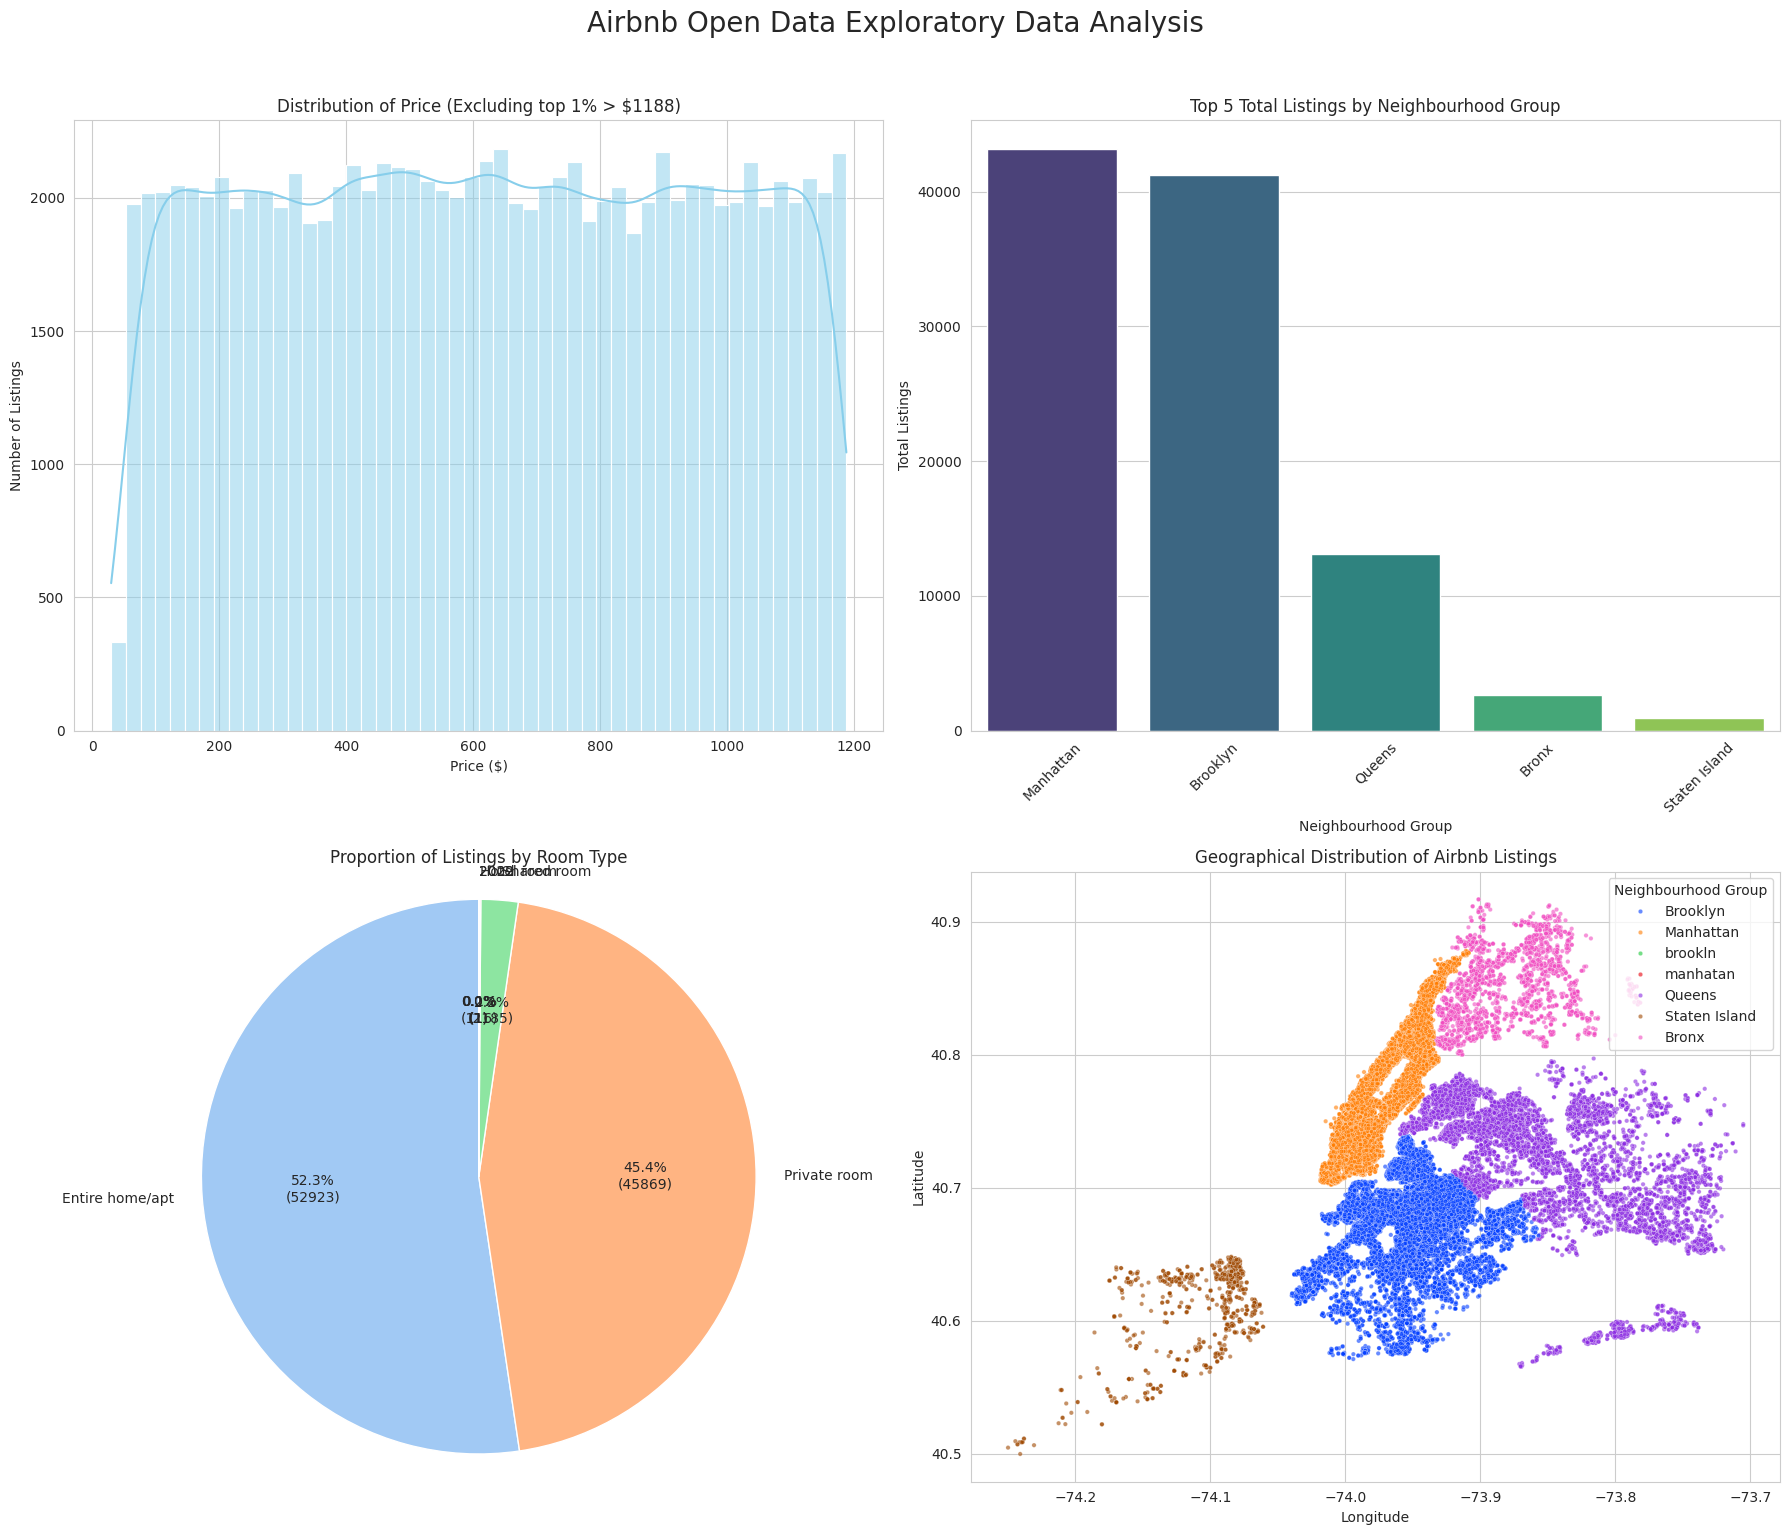

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for better aesthetics
sns.set_style("whitegrid")

# --- 1. Data Loading ---
print("--- 1. Loading Data ---")
FILE_NAME = '1730285881-Airbnb_Open_Data.csv'

try:
    # Use on_bad_lines='skip' to handle formatting errors in the raw CSV file
    df = pd.read_csv(FILE_NAME, low_memory=False, on_bad_lines='skip')
    print(f"Data loaded successfully from {FILE_NAME}. Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: The file '{FILE_NAME}' was not found.")
    exit()

# Standardizing column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# --- 2. Data Cleaning and Preprocessing ---

# Function to clean currency columns (removes $, , and handles NaNs)
def clean_currency(value):
    if pd.isna(value):
        return np.nan
    try:
        return float(str(value).replace('$', '').replace(',', ''))
    except:
        return np.nan

print("\n--- 2. Cleaning 'price' and 'service_fee' ---")
# Apply cleaning function to both columns
df['price'] = df['price'].apply(clean_currency)
df['service_fee'] = df['service_fee'].apply(clean_currency)

# Drop rows where 'price' is missing or 0, as this is critical for analysis
df.dropna(subset=['price'], inplace=True)
df = df[df['price'] > 0]

# --- 3. Exploratory Data Analysis (EDA) and Visualization ---

# Set up the figure for all plots
plt.figure(figsize=(18, 15))
plt.suptitle('Airbnb Open Data Exploratory Data Analysis', fontsize=20, y=1.02)

# ====================================================
# 3.1. Visualization 1: Distribution of Listing Prices (Histogram)
# ====================================================
print("\n--- 3.1. Generating Price Distribution Plot (price_distribution.png) ---")
# Filter out extreme outliers (top 1% of prices) for a clearer visualization
price_limit = df['price'].quantile(0.99)
df_price_clean = df[df['price'] <= price_limit]

plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
sns.histplot(df_price_clean['price'], bins=50, kde=True, color='skyblue')
plt.title(f'Distribution of Price (Excluding top 1% > ${price_limit:.0f})')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.savefig('price_distribution.png')


# ====================================================
# 3.2. Visualization 2: Total Listings by Neighbourhood Group (Bar Plot)
# ====================================================
print("--- 3.2. Generating Listings by Neighbourhood Group Plot (listings_by_group.png) ---")
listings_by_group = df['neighbourhood_group'].value_counts().sort_values(ascending=False).head(5)

plt.subplot(2, 2, 2)
sns.barplot(x=listings_by_group.index, y=listings_by_group.values, palette='viridis')
plt.title('Top 5 Total Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Total Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('listings_by_group.png')


# ====================================================
# 3.3. Visualization 3: Listings by Room Type (Pie Chart)
# ====================================================
print("--- 3.3. Generating Listings by Room Type Plot (room_type_pie.png) ---")
room_type_counts = df['room_type'].value_counts()
labels = room_type_counts.index
sizes = room_type_counts.values

# Define a function to calculate percentage and absolute counts for the pie chart
def func(pct, allvalues):
    absolute = int(np.round(pct/100.*np.sum(allvalues)))
    return "{:.1f}%\n({:d})".format(pct, absolute)

plt.subplot(2, 2, 3)
plt.pie(sizes, labels=labels, autopct=lambda pct: func(pct, sizes), startangle=90, colors=sns.color_palette('pastel'))
plt.title('Proportion of Listings by Room Type')
plt.axis('equal') # Ensures that pie is drawn as a circle.
plt.tight_layout()
plt.savefig('room_type_pie.png')


# ====================================================
# 3.4. Visualization 4: Geographical Distribution of Listings (Scatter Plot)
# ====================================================
print("--- 3.4. Generating Geographical Distribution Plot (geographical_distribution.png) ---")
# Ensure lat/long columns are numeric and drop missing values for plotting
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['long'] = pd.to_numeric(df['long'], errors='coerce')
df_geo = df.dropna(subset=['lat', 'long', 'neighbourhood_group'])

plt.subplot(2, 2, 4)
# Use a scatter plot where color indicates neighbourhood group
# and alpha controls transparency for density visualization
sns.scatterplot(x='long', y='lat', hue='neighbourhood_group', data=df_geo,
                palette='bright', s=10, alpha=0.6)
plt.title('Geographical Distribution of Airbnb Listings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighbourhood Group', loc='upper right')
plt.tight_layout()
plt.savefig('geographical_distribution.png')

print("\n--- Project Complete ---")
print("Four image files have been saved to your session: price_distribution.png, listings_by_group.png, room_type_pie.png, and geographical_distribution.png.")